# initiating 

In [1]:
import random
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
def plot(results, title,victim):
    import matplotlib.pyplot as plt
    fig = plt.figure(dpi=600)
    fig, ax = plt.subplots()
    markers = ['+', 'x'] # Add your desired markers here for Degree and betweeness in targated attacks 
    for d in range(len(results)):
        data = results[d]
        x = [item[0] for item in data]
        y = [item[1] for item in data]
        marker_idx = d % len(markers) # Choose marker based on index of the result
        ax.plot(x, y, marker=markers[marker_idx], linewidth=0.5, markersize=6,)

    ax.set_xlabel('#' f'{victim} batches removed')
    ax.set_ylabel(r'$|N_{LCC}| / |N| $')
    ax.set_title(f'{title}  ')
    plt.legend()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

In [3]:
# batching the netwrok into N batches
def batch_list(lst,N):
    # Divide a list into batches of an equal number of items 
    batch_size = (len(lst) + (N-1)) // N  # Calculate the batch size
    if batch_size==0:
        input(lst)
    num_batches = (len(lst) + batch_size - 1) // batch_size
    batches = [lst[i*batch_size:(i+1)*batch_size] for i in range(num_batches)]
    return batches
    

def simple_batching(lst,batch_size): 
    
    if batch_size==0:
        input(lst)
    num_batches = (len(lst) + batch_size - 1) // batch_size
    batches = [lst[i*batch_size:(i+1)*batch_size] for i in range(num_batches)]
    return batches

def cal_batchSize(numOfBtachs,lst):
    batches_size= (len(lst) + (numOfBtachs-1)) // numOfBtachs
    return batches_size


In [4]:
def LCC(G):
    connected_components = list(nx.connected_components(G))
    if len(connected_components) > 0:
        subG = G.subgraph(max(connected_components, key=len))
        if len(subG.nodes())>1: 
            return subG
        else:
            return None
    else:
        # Handle the case when there are no connected components
        return None


# Random Attack

## Nodes Random Attacks 

C:\Users\fayoy\AppData\Local\Temp\ipykernel_33568\3836501759.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\fayoy\AppData\Local\Temp\ipykernel_33568\3836501759.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


<Figure size 3840x2880 with 0 Axes>

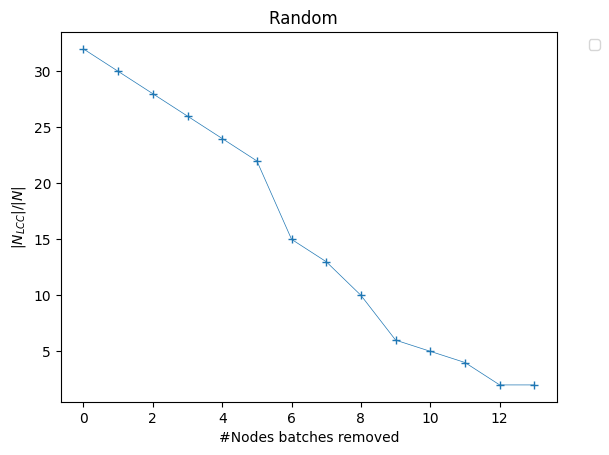

In [9]:
G = nx.karate_club_graph()
def randomN_AttckSim(G):

    results = []  
    V = list(G.nodes)
    random.shuffle(V)
    batches = batch_list(V,30)
    # print(batches)
    result = []
    for b in range(len(batches)):
        # print("newBatches[b] = ",batches[b])
        G.remove_nodes_from(batches[b])
 
        largest_component = LCC(G)
        if largest_component:
            result.append([b, len(largest_component)])
 
    results.append(result)
    return results
rndE_results = randomN_AttckSim(G)
plot(rndE_results, 'Random', 'Nodes')

## Edges Random Attacks 

C:\Users\fayoy\AppData\Local\Temp\ipykernel_33568\3836501759.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\fayoy\AppData\Local\Temp\ipykernel_33568\3836501759.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


<Figure size 3840x2880 with 0 Axes>

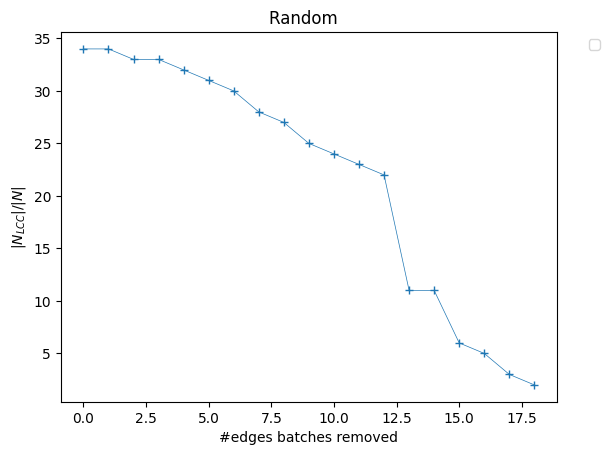

In [10]:
G = nx.karate_club_graph()
def randomE_AttckSim(G):
    results = []
    
    E = list(G.edges)
    random.shuffle(E)
    batches = batch_list(E,20)
    
    # batches = batch_list(W,20)
    # newBatches = []
    # for b in batches:
    #     newBatches.append(b[0])
    # print(batches)

    result = []
    for b in range(len(batches)):
        G.remove_edges_from(batches[b])            
        largest_component = LCC(G)
        if largest_component:
            result.append([b, len(largest_component)])

    results.append(result)
    return results
rndE_results = randomE_AttckSim(G)
plot(rndE_results, 'Random', 'edges')


# Targated Attack

In [11]:
centr = ['Degree','Betweenness']

#return an order list of only the only one CI specified by the paramenter low to hight for recusive method 
def CI_Node_orderd_list2(G,centrality ):
    CI_Dict =centrality(G)
    CI_sortedDict = {k: v for k, v in sorted(CI_Dict.items(), key=lambda item: item[1])}
    CI_sortedList= list(CI_sortedDict.keys())
    return CI_sortedList  

#  return an order edge list of only the only one CI specified by the paramenter low to hight 
def weighted_edges(G, centrality): #  from [8]
    '''return a weighted edges'''
    CI_Dict = centrality(G)
    W = []
    for u,v in G.edges():
        W.append([u, v, CI_Dict[u]*CI_Dict[v]])
    return sorted(W, key=lambda x: x[2])


In [12]:
def recalculateRecursionGen(G,batches,batches_size,centrality,i,results, victim):


    result = []
    if victim == "Node Attack":
        R = batches[i] # Nodes to be removed...
        G.remove_nodes_from(R)
    else:
        R = [(u,v) for u,v,_ in batches[i]] # edges to be removed...
        G.remove_edges_from(R)

    largest_component = LCC(G)
    print(largest_component)
    if largest_component:
        result.append([len(results)+1, len(largest_component)])       
    
    results.append(result)
    i-=1

    if victim == "Node Attack":
        Ranked_lists = CI_Node_orderd_list2(G,centrality)
    else:    
        Ranked_lists = weighted_edges(G,centrality) 
    
    neWbatches = simple_batching(Ranked_lists,batches_size) # batchin the nodes into an BN of batches 
    if  i<=0  : return results
    else: return recalculateRecursionGen(G, neWbatches,batches_size,centrality, i ,results,victim)

## Nodes Targeted Attacks 

In [13]:
G = nx.karate_club_graph()
def simulationREC(centrality,numOfBtachs):
    G = nx.karate_club_graph()
    Ranked_lists = CI_Node_orderd_list2(G,nx.degree_centrality) 
    batches_size= cal_batchSize(numOfBtachs,Ranked_lists)   
    batches = simple_batching(Ranked_lists,batches_size)
    
    results =recalculateRecursionGen(G,batches,batches_size,centrality,len(batches)-1,[],"Node Attack")


    return results

Graph named "Zachary's Karate Club" with 26 nodes and 39 edges
Graph named "Zachary's Karate Club" with 10 nodes and 11 edges
Graph named "Zachary's Karate Club" with 8 nodes and 9 edges
Graph named "Zachary's Karate Club" with 5 nodes and 6 edges
Graph named "Zachary's Karate Club" with 5 nodes and 4 edges
Graph named "Zachary's Karate Club" with 2 nodes and 1 edges
None
None
None
None
None
None
None
None
None
None


C:\Users\fayoy\AppData\Local\Temp\ipykernel_33568\3836501759.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\fayoy\AppData\Local\Temp\ipykernel_33568\3836501759.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


<Figure size 3840x2880 with 0 Axes>

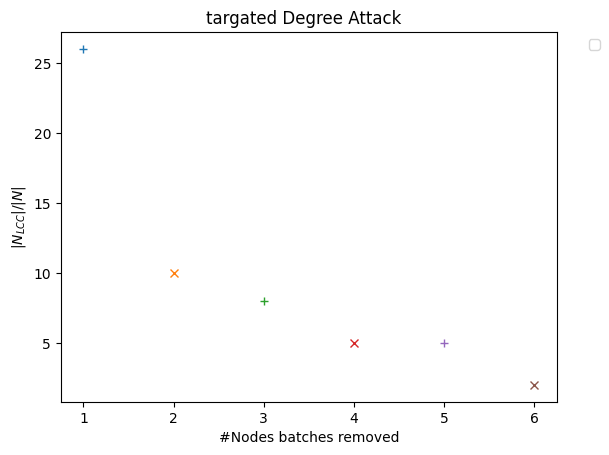

Graph named "Zachary's Karate Club" with 26 nodes and 39 edges
Graph named "Zachary's Karate Club" with 10 nodes and 11 edges
Graph named "Zachary's Karate Club" with 5 nodes and 6 edges
Graph named "Zachary's Karate Club" with 5 nodes and 6 edges
Graph named "Zachary's Karate Club" with 4 nodes and 3 edges
Graph named "Zachary's Karate Club" with 2 nodes and 1 edges
None
None
None
None
None
None
None
None
None
None


<Figure size 3840x2880 with 0 Axes>

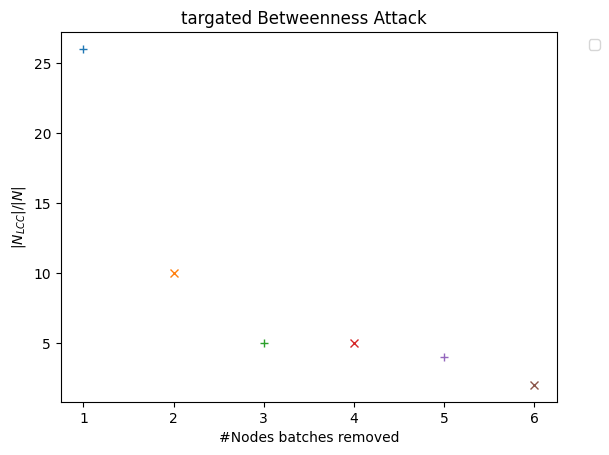

In [14]:
centralities = [nx.degree_centrality, nx.betweenness_centrality]
for i in range(len(centralities)):
    TA_results = simulationREC(centralities[i],30)

    plot(TA_results, f'targated {centr[i]} Attack', 'Nodes')

#conclution after removing 6 batches the LCC disapears for both centrulities, 6 batche = 6*2(size batches) = after the removal of 18 nodes 

## Edges Targeted Attacks 

In [15]:
 
G = nx.karate_club_graph()

def E_simulationREC(centrality,numOfBtachs):
    G = nx.karate_club_graph()
    Ranked_lists = weighted_edges(G,nx.degree_centrality) 
    batches_size= cal_batchSize(numOfBtachs,Ranked_lists)   
    batches = simple_batching(Ranked_lists,batches_size)

    results =recalculateRecursionGen(G,batches,batches_size,centrality,len(batches)-1,[],"edge attck")


    return results

Graph named "Zachary's Karate Club" with 34 nodes and 75 edges
Graph named "Zachary's Karate Club" with 34 nodes and 72 edges
Graph named "Zachary's Karate Club" with 34 nodes and 69 edges
Graph named "Zachary's Karate Club" with 34 nodes and 66 edges
Graph named "Zachary's Karate Club" with 34 nodes and 63 edges
Graph named "Zachary's Karate Club" with 34 nodes and 60 edges
Graph named "Zachary's Karate Club" with 34 nodes and 57 edges
Graph named "Zachary's Karate Club" with 34 nodes and 54 edges
Graph named "Zachary's Karate Club" with 34 nodes and 51 edges
Graph named "Zachary's Karate Club" with 29 nodes and 42 edges
Graph named "Zachary's Karate Club" with 29 nodes and 39 edges
Graph named "Zachary's Karate Club" with 29 nodes and 36 edges
Graph named "Zachary's Karate Club" with 19 nodes and 22 edges
Graph named "Zachary's Karate Club" with 16 nodes and 17 edges
Graph named "Zachary's Karate Club" with 16 nodes and 16 edges
Graph named "Zachary's Karate Club" with 6 nodes and 6 

C:\Users\fayoy\AppData\Local\Temp\ipykernel_33568\3836501759.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\fayoy\AppData\Local\Temp\ipykernel_33568\3836501759.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


<Figure size 3840x2880 with 0 Axes>

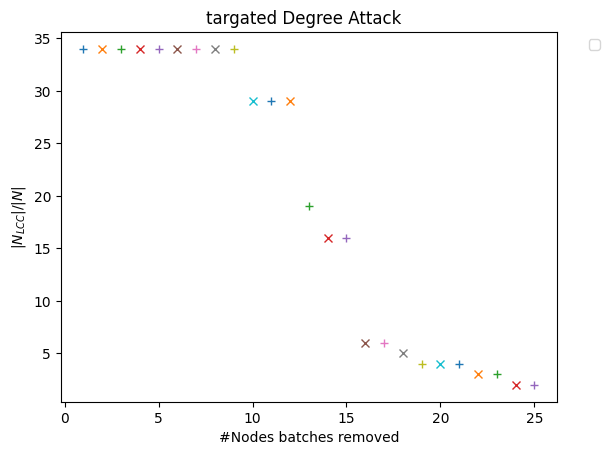

Graph named "Zachary's Karate Club" with 34 nodes and 75 edges
Graph named "Zachary's Karate Club" with 34 nodes and 72 edges
Graph named "Zachary's Karate Club" with 34 nodes and 69 edges
Graph named "Zachary's Karate Club" with 34 nodes and 66 edges
Graph named "Zachary's Karate Club" with 34 nodes and 63 edges
Graph named "Zachary's Karate Club" with 19 nodes and 36 edges
Graph named "Zachary's Karate Club" with 19 nodes and 34 edges
Graph named "Zachary's Karate Club" with 19 nodes and 32 edges
Graph named "Zachary's Karate Club" with 19 nodes and 30 edges
Graph named "Zachary's Karate Club" with 19 nodes and 29 edges
Graph named "Zachary's Karate Club" with 19 nodes and 26 edges
Graph named "Zachary's Karate Club" with 9 nodes and 10 edges
Graph named "Zachary's Karate Club" with 9 nodes and 13 edges
Graph named "Zachary's Karate Club" with 9 nodes and 13 edges
Graph named "Zachary's Karate Club" with 9 nodes and 13 edges
Graph named "Zachary's Karate Club" with 9 nodes and 12 edg

<Figure size 3840x2880 with 0 Axes>

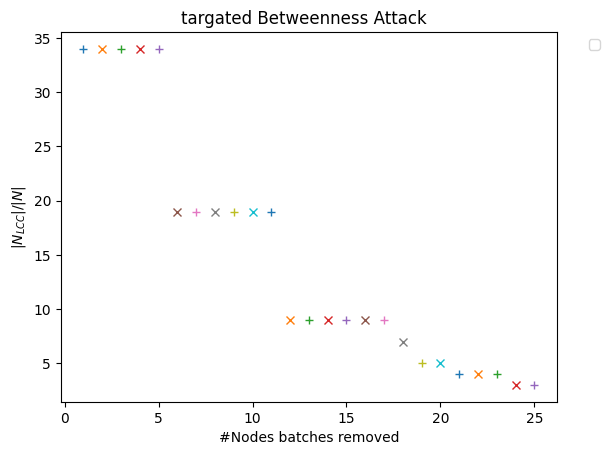

In [16]:
centralities = [nx.degree_centrality, nx.betweenness_centrality]
for i in range(len(centralities)):
    TA_results = E_simulationREC(centralities[i],30)

    plot(TA_results, f'targated {centr[i]} Attack', 'Nodes')

# Realistic/Probabilistic Targated Attack